In [1]:
import pandas as pd

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data_1 = pd.read_csv(r"C:\Users\BOB\Downloads\TECHCRUSH COHORT 3 - TRAINING\Q&A - TASK III\Pizza+Place+Sales\pizza_sales\orders.csv")

In [4]:
data_2 = pd.read_csv(r"C:\Users\BOB\Downloads\TECHCRUSH COHORT 3 - TRAINING\Q&A - TASK III\Pizza+Place+Sales\pizza_sales\order_details.csv")

In [5]:
data_3 = pd.read_csv(r"C:\Users\BOB\Downloads\TECHCRUSH COHORT 3 - TRAINING\Q&A - TASK III\Pizza+Place+Sales\pizza_sales\pizzas.csv")

In [6]:
data_4 = pd.read_csv(r"C:\Users\BOB\Downloads\TECHCRUSH COHORT 3 - TRAINING\Q&A - TASK III\Pizza+Place+Sales\pizza_sales\pizza_types.csv", encoding = "latin1")

In [7]:
data_1.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [8]:
data_2.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [9]:
data_3.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [10]:
data_4.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


### Merge the Dataset: Order with Order_details

In [152]:
merged_1 = pd.merge(data_1, data_2, on="order_id", how="inner")  # or "left", "right"

In [154]:
merged_2 = pd.merge(merged_1, data_3, on="pizza_id", how="inner")  # or "left", "right"

In [156]:
final_data = pd.merge(merged_2, data_4, on="pizza_type_id", how="inner")  # or "left", "right"

In [158]:
final_data.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients
0,1,2015-01-01,11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,2,2015-01-01,11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,2,2015-01-01,11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,2,2015-01-01,11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [160]:
final_data.isnull().sum()

order_id            0
date                0
time                0
order_details_id    0
pizza_id            0
quantity            0
pizza_type_id       0
size                0
price               0
name                0
category            0
ingredients         0
dtype: int64

In [162]:
final_data["date"] = pd.to_datetime(final_data["date"])

In [164]:
print(final_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          48620 non-null  int64         
 1   date              48620 non-null  datetime64[ns]
 2   time              48620 non-null  object        
 3   order_details_id  48620 non-null  int64         
 4   pizza_id          48620 non-null  object        
 5   quantity          48620 non-null  int64         
 6   pizza_type_id     48620 non-null  object        
 7   size              48620 non-null  object        
 8   price             48620 non-null  float64       
 9   name              48620 non-null  object        
 10  category          48620 non-null  object        
 11  ingredients       48620 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(7)
memory usage: 4.5+ MB
None


In [166]:
final_data["time"] = final_data["date"]

In [168]:
print(final_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          48620 non-null  int64         
 1   date              48620 non-null  datetime64[ns]
 2   time              48620 non-null  datetime64[ns]
 3   order_details_id  48620 non-null  int64         
 4   pizza_id          48620 non-null  object        
 5   quantity          48620 non-null  int64         
 6   pizza_type_id     48620 non-null  object        
 7   size              48620 non-null  object        
 8   price             48620 non-null  float64       
 9   name              48620 non-null  object        
 10  category          48620 non-null  object        
 11  ingredients       48620 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(3), object(6)
memory usage: 4.5+ MB
None


### Extract hour from Datetime

In [246]:
final_data['hour'] = final_data['date'].dt.hour

In [248]:
final_data['hour'] = final_data['time'].dt.hour

In [250]:
print("Peak Hours of Sales (by Revenue):")
print(peak_hours)

Peak Hours of Sales (by Revenue):
hour
0    817860.05
Name: total_price, dtype: float64


### Total Revenue

The business generated a Total Revenue of $817,860.05 from pizza sales within the recorded period. <br>  This figure represents the combined monetary value of all pizza orders after accounting for both the unit price and the quantities sold. <br> The revenue value can serve as a baseline for: <br>1. Evaluating business performance during the sales period. <br>2. Conducting comparative analysis with other periods. <br>3. Identifying opportunities to increase sales through promotions, upselling, or expanding product offerings.

In [253]:
final_data['total_price'] = final_data['price'] * final_data['quantity']
total_revenue = final_data['total_price'].sum()

In [255]:
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $817,860.05


## Total Quantity Sold

This figure represents the combined sales volume across all pizza categories and order records.  
<br> The total quantity sold is a useful metric to understand overall demand and customer purchase behaviour.

In [183]:
total_quantity = final_data['quantity'].sum()

In [185]:
print(f"Total Quantity Sold: {total_quantity}\n")

Total Quantity Sold: 49574



### Total Order

In [188]:
total_orders = final_data['order_id'].nunique()

In [190]:
print(f"Total Orders: {total_orders}")

Total Orders: 21350


### Number of Pizza Types


In [193]:
# Find columns that contain the word 'type'

print([col for col in final_data.columns if 'type' in col.lower()])

['pizza_type_id']


In [195]:
pizza_type_id = final_data['pizza_type_id'].nunique()

In [197]:
print(f"Number of Pizza Types: {pizza_type_id}")

Number of Pizza Types: 32


### Average Pizza Price

In [200]:
average_price = final_data['price'].mean()

In [202]:
print(f"Average Price of Pizzas: ₦{average_price:,.2f}")

Average Price of Pizzas: ₦16.49


### Peak Hours of Sales

In [205]:
peak_hours = final_data.groupby('hour')['total_price'].sum().sort_values(ascending=False)

In [207]:
print("Peak Hours of Sales (by Revenue):\n")
for hour, revenue in peak_hours.items():
    print(f"Hour {hour:02d}: ₦{revenue:,.2f}")

Peak Hours of Sales (by Revenue):

Hour 00: ₦817,860.05


### Sales by Day of Week

In [210]:
final_data['weekday'] = final_data['date'].dt.day_name()

In [212]:
sales_by_day = final_data.groupby('weekday')['price'].sum().sort_values(ascending=False)

In [214]:
print("Sales by Day of the Week:\n")
for day, revenue in sales_by_day.items():
    print(f"{day}: ₦{revenue:,.2f}")

Sales by Day of the Week:

Friday: ₦133,773.90
Thursday: ₦120,912.45
Saturday: ₦120,865.30
Wednesday: ₦112,006.45
Tuesday: ₦111,764.70
Monday: ₦105,357.15
Sunday: ₦97,264.75


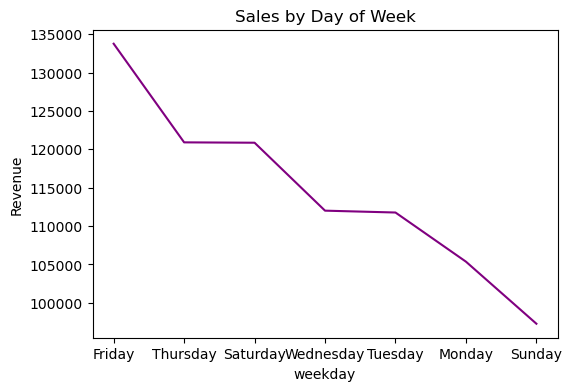

In [216]:
# Sales by Day of Week Plot

plt.figure(figsize=(6,4))
sales_by_day.plot(kind='line', color='purple')
plt.title('Sales by Day of Week')
plt.ylabel('Revenue')
plt.show()

### Which day of the week is when sales are made the most?

In [219]:
sales_by_day = final_data.groupby('weekday')['price'].sum().sort_values(ascending=False)
print(sales_by_day)

weekday
Friday       133773.90
Thursday     120912.45
Saturday     120865.30
Wednesday    112006.45
Tuesday      111764.70
Monday       105357.15
Sunday        97264.75
Name: price, dtype: float64


### Top 5 Best Selling Pizza

In [222]:
# Group by pizza type and sum quantity sold
top_pizzas = final_data.groupby('pizza_type_id')['quantity'].sum().sort_values(ascending=False).head(5)

In [224]:
print("Top 5 Best-Selling Pizzas:\n")
for pizza, qty in top_pizzas.items():
    print(f"{pizza}: {qty:,} sold")

Top 5 Best-Selling Pizzas:

classic_dlx: 2,453 sold
bbq_ckn: 2,432 sold
hawaiian: 2,422 sold
pepperoni: 2,418 sold
thai_ckn: 2,371 sold


In [226]:
top_pizzas = final_data.groupby('pizza_type_id')['quantity'].sum().sort_values(ascending=False).head(5)

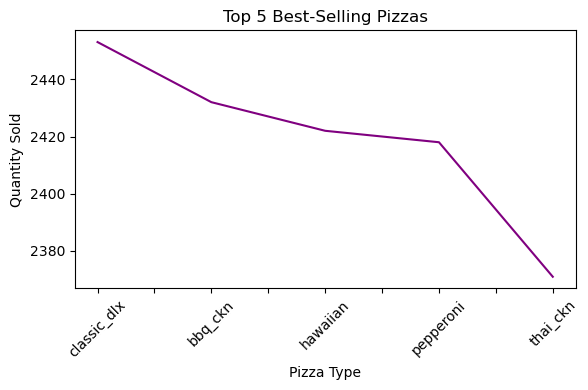

In [228]:
# Plot the line chart

plt.figure(figsize=(6, 4))
top_pizzas.plot(kind='line', color='purple')
plt.title('Top 5 Best-Selling Pizzas')
plt.xlabel('Pizza Type')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly Sales Trend

In [267]:
final_data['month'] = final_data['time'].dt.month_name()
monthly_sales = final_data.groupby('month')['total_price'].sum()

In [269]:
# Print results

print("Monthly Sales Trend:\n")
for month, revenue in monthly_sales.items():
    print(f"{month}: ₦{revenue:,.2f}")

Monthly Sales Trend:

April: ₦68,736.80
August: ₦68,278.25
December: ₦64,701.15
February: ₦65,159.60
January: ₦69,793.30
July: ₦72,557.90
June: ₦68,230.20
March: ₦70,397.10
May: ₦71,402.75
November: ₦70,395.35
October: ₦64,027.60
September: ₦64,180.05


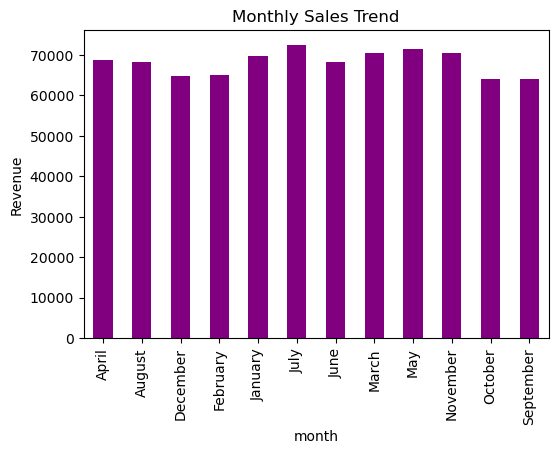

In [271]:
# Monthly Sales Trend Plot

plt.figure(figsize=(6,4))
monthly_sales.plot(kind='bar', color='purple')
plt.title('Monthly Sales Trend')
plt.ylabel('Revenue')
plt.show()

Looking at the Monthly Sales Trend chart:

- The revenue stays relatively high and stable across the months, ranging roughly between 65,000 and 72000.
- There is a slight decline over time - earlier months, like July, May, and March) show slightly higher revenues compared to later months like December, September, and October).
- This suggests that while sales are strong and consistent, there may be a gradual downward trend as the year progresses. <br> No sharp spikes or drastic drops are visible, which indicates a steady Sales Performance overall, with ONLY mild fluctations.

However, Sales Revenue is generally stable but shows a slow, slight decline across the months.

### Underperforming Pizzas

In [275]:
low_sellers = final_data.groupby('name')['quantity'].sum().sort_values().head(5)

In [277]:
print("Bottom 5 Least-Selling Pizzas:\n")
for pizza, qty in low_sellers.items():
    print(f"{pizza}: {qty:,} sold")

Bottom 5 Least-Selling Pizzas:

The Brie Carre Pizza: 490 sold
The Mediterranean Pizza: 934 sold
The Calabrese Pizza: 937 sold
The Spinach Supreme Pizza: 950 sold
The Soppressata Pizza: 961 sold


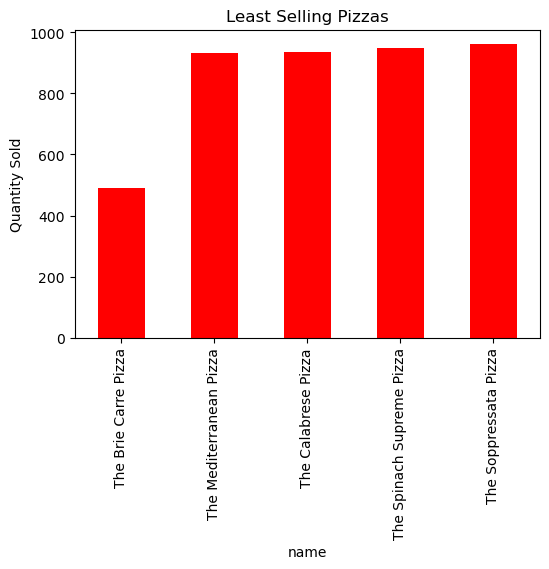

In [243]:
# Underperforming Pizzas Plot

plt.figure(figsize=(6,4))
low_sellers.plot(kind='bar', color='red')
plt.title('Least Selling Pizzas')
plt.ylabel('Quantity Sold')
plt.show()